# §4.4.2 — Consistencia temporal con la Fiscalía General del Estado (FGE)

**Objetivo:** contrastar los patrones temporales del modelo (entrenado sobre datos MDI, 2019–2025)
contra una segunda fuente institucional **independiente**: las Noticias de Delito (NDD) de la FGE,
extraídas del SIAF (archivo `INFORME_GUAYAQUIL.xlsx`).

Se compara **solo el eje temporal** (año y franja horaria). NO se compara el eje espacial,
porque la FGE trabaja a nivel de **parroquia** (22) y el modelo a nivel de **subcircuito** (240):
agregar predicciones a parroquia introduce ruido que debilita el argumento.

> **Importante (marco de interpretación):** la FGE mide **frecuencia** (cantidad de NDD) y el modelo
> predice **gravedad**. Por eso esto se reporta como *consistencia contextual*, no como validación formal.
> Lo que se evalúa es si las franjas/años donde se concentra la actividad delictiva según una institución
> independiente coinciden con el comportamiento temporal del modelo y de sus datos de entrada.


In [1]:
# =====================================================================
# 0. PARÁMETROS — EDITA ESTAS RUTAS Y AJUSTES SEGÚN TU ENTORNO
# =====================================================================
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import joblib

# --- Rutas (ajústalas a tu proyecto) ---
RUTA_FGE      = r"C:\Users\jhono\Downloads\Proyecto Titulación\INFORME GUAYAQUIL (1).xlsx"     # anexo FGE (este mismo archivo)
RUTA_MDI      = r"C:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_detenidosaprehendidos_guayaquil_2019_2025_con_delitos_y_tipo_dato.csv"          # tu dataset MDI limpio (salida notebook 01), 76.860 reg.
RUTA_MODELO   = r"C:\Users\jhono\Downloads\Proyecto Titulación\SISTEMA_PREDICTIVO\backend\model\modelo_final.pkl"            # LightGBM ganador
# encoders.pkl solo es necesario si tu dataset NO está ya codificado para el modelo
RUTA_ENCODERS = r"C:\Users\jhono\Downloads\Proyecto Titulación\SISTEMA_PREDICTIVO\backend\model\encoders.pkl"

# --- Nombres de columnas en tu dataset MDI ---
COL_ANIO = "anio"
COL_HORA = "hora"          # hora 0-23

# --- Orden ESTRICTO de las 12 features del modelo ---
FEATURES = ["anio","mes","dia_semana","es_fin_de_semana","hora","codigo_distrito",
            "codigo_circuito","codigo_subcircuito","freq_subcircuito","codigo_iccs",
            "macro_lugar","flag_coord"]

# --- Definición de franjas horarias (CONVENCIÓN ESTÁNDAR — VERIFICA CON LA FGE) ---
# La FGE NO documenta los cortes exactos en el anexo. Si su definición difiere, cámbiala aquí.
def hora_a_franja(h):
    h = int(h)
    if   0 <= h <= 5:   return "MADRUGADA"
    elif 6 <= h <= 11:  return "MAÑANA"
    elif 12 <= h <= 17: return "TARDE"
    else:               return "NOCHE"

ORDEN_FRANJA = ["MADRUGADA","MAÑANA","TARDE","NOCHE"]
PERIODO = (2019, 2025)
print("Parámetros cargados.")

Parámetros cargados.


In [2]:
# =====================================================================
# 1. FGE — cargar, limpiar y construir perfiles temporales
# =====================================================================
fge = pd.read_excel(RUTA_FGE, sheet_name="Datos", header=12)
fge = fge.dropna(axis=1, how="all")
fge.columns = [str(c).strip().rstrip(".").strip() for c in fge.columns]
fge = fge.dropna(subset=["DELITO"]).rename(columns={"TOTAL NDD":"TOTAL_NDD"})
fge["AÑO_INCIDENTE"] = fge["AÑO_INCIDENTE"].astype(int)
fge["MES_INCIDENTE"] = fge["MES_INCIDENTE"].astype(int)
fge = fge[(fge["AÑO_INCIDENTE"]>=PERIODO[0]) & (fge["AÑO_INCIDENTE"]<=PERIODO[1])].copy()

fge_year  = fge.groupby("AÑO_INCIDENTE")["TOTAL_NDD"].sum()
fge_month = fge.groupby("MES_INCIDENTE")["TOTAL_NDD"].sum()
fge_band  = fge.groupby("GRUPO_HORA_INCIDENTE")["TOTAL_NDD"].sum().reindex(ORDEN_FRANJA)

print(f"FGE {PERIODO[0]}-{PERIODO[1]}: {len(fge):,} filas | {int(fge['TOTAL_NDD'].sum()):,} NDD totales")
print("\nNDD por año:\n", fge_year)
print("\nNDD por franja:\n", fge_band, "\n% franja:\n", (fge_band/fge_band.sum()*100).round(1))
# Valores esperados de referencia (control): 2019=70617 ... 2023=80312 ; TARDE 34.3%, MAÑANA 29.5%

FGE 2019-2025: 39,011 filas | 477,527 NDD totales

NDD por año:
 AÑO_INCIDENTE
2019    70617
2020    54404
2021    62712
2022    71888
2023    80312
2024    75300
2025    62294
Name: TOTAL_NDD, dtype: int64

NDD por franja:
 GRUPO_HORA_INCIDENTE
MADRUGADA     53526
MAÑANA       140796
TARDE        163591
NOCHE        119614
Name: TOTAL_NDD, dtype: int64 
% franja:
 GRUPO_HORA_INCIDENTE
MADRUGADA    11.2
MAÑANA       29.5
TARDE        34.3
NOCHE        25.0
Name: TOTAL_NDD, dtype: float64


In [3]:
# =====================================================================
# 2. MDI — perfil temporal de FRECUENCIA de los datos de entrada del modelo
#    (cada registro = una aprehensión/detención)
# =====================================================================
mdi = pd.read_csv(RUTA_MDI, sep=";", low_memory=False)

# Normalizar nombres y construir las columnas temporales que usa el resto del notebook.
if COL_ANIO not in mdi.columns and "fecha_detencion_aprehension" in mdi.columns:
    mdi[COL_ANIO] = pd.to_datetime(mdi["fecha_detencion_aprehension"], dayfirst=True, errors="coerce").dt.year
if COL_HORA not in mdi.columns and "hora_detencion_aprehension" in mdi.columns:
    mdi[COL_HORA] = pd.to_datetime(mdi["hora_detencion_aprehension"], errors="coerce").dt.hour

mdi = mdi.dropna(subset=[COL_ANIO, COL_HORA]).copy()
mdi[COL_ANIO] = mdi[COL_ANIO].astype(int)
mdi[COL_HORA] = mdi[COL_HORA].astype(int)
mdi["FRANJA"] = mdi[COL_HORA].apply(hora_a_franja)

mdi_year = mdi.groupby(COL_ANIO).size()
mdi_year = mdi_year[(mdi_year.index>=PERIODO[0]) & (mdi_year.index<=PERIODO[1])]
mdi_band = mdi.groupby("FRANJA").size().reindex(ORDEN_FRANJA)

print(f"MDI: {len(mdi):,} registros")
print("\nRegistros por año:\n", mdi_year)
print("\nRegistros por franja:\n", mdi_band, "\n% franja:\n", (mdi_band/mdi_band.sum()*100).round(1))

MDI: 76,860 registros

Registros por año:
 anio
2019    11988
2020    11272
2021    12219
2022    11514
2023    10650
2024     9403
2025     9814
dtype: int64

Registros por franja:
 FRANJA
MADRUGADA     9714
MAÑANA       17981
TARDE        29263
NOCHE        19902
dtype: int64 
% franja:
 FRANJA
MADRUGADA    12.6
MAÑANA       23.4
TARDE        38.1
NOCHE        25.9
dtype: float64


In [4]:
# =====================================================================
# 3. MODELO — gravedad PREDICHA por franja y por año
#    danger score = (0*P(BAJA)+1*P(MEDIA)+2*P(ALTA)+3*P(CRÍTICA))/3 * 100
#    También % de registros clasificados ALTA o CRÍTICA.
# =====================================================================
modelo_ok = False
try:
    modelo = joblib.load(RUTA_MODELO)

    # Construir matriz de features en orden estricto.
    # Tu dataset MDI debe contener ya las 12 columnas codificadas igual que en el entrenamiento.
    X = mdi[FEATURES].copy()

    proba = modelo.predict_proba(X)                 # columnas alineadas a modelo.classes_
    clases = list(modelo.classes_)                  # esperado [0,1,2,3] = BAJA,MEDIA,ALTA,CRITICA
    pesos = np.array([0,1,2,3], dtype=float)         # peso por clase ordinal
    # reordenar pesos según el orden real de classes_ (por robustez)
    peso_por_clase = {0:0,1:1,2:2,3:3}
    w = np.array([peso_por_clase[c] for c in clases])
    danger = (proba * w).sum(axis=1) / 3 * 100       # 0-100

    pred_clase = proba.argmax(axis=1)
    pred_clase = np.array([clases[i] for i in pred_clase])
    es_grave = np.isin(pred_clase, [2,3]).astype(int)  # ALTA o CRITICA

    mdi["_danger"] = danger
    mdi["_grave"]  = es_grave

    sev_band = mdi.groupby("FRANJA")["_danger"].mean().reindex(ORDEN_FRANJA)
    pct_grave_band = (mdi.groupby("FRANJA")["_grave"].mean()*100).reindex(ORDEN_FRANJA)
    sev_year = mdi.groupby(COL_ANIO)["_danger"].mean()
    sev_year = sev_year[(sev_year.index>=PERIODO[0]) & (sev_year.index<=PERIODO[1])]

    print("Danger score medio por franja:\n", sev_band.round(2))
    print("\n% ALTA+CRÍTICA por franja:\n", pct_grave_band.round(1))
    print("\nDanger score medio por año:\n", sev_year.round(2))
    modelo_ok = True
except Exception as e:
    print("AVISO: no se pudo predecir con el modelo en este entorno.")
    print("Razon:", repr(e))
    print("\nLa comparación a nivel de DATOS (MDI vs FGE) de las celdas siguientes")
    print("igual funciona. Si tu dataset ya está codificado, revisa el orden de FEATURES.")

AVISO: no se pudo predecir con el modelo en este entorno.
Razon: KeyError("['mes', 'dia_semana', 'es_fin_de_semana', 'freq_subcircuito', 'macro_lugar'] not in index")

La comparación a nivel de DATOS (MDI vs FGE) de las celdas siguientes
igual funciona. Si tu dataset ya está codificado, revisa el orden de FEATURES.


In [5]:
# =====================================================================
# 4. COMPARACIÓN ANUAL (2019-2025, n=7) — eje temparal grueso
#    Spearman + acuerdo direccional año a año.
#    También se reporta la sub-ventana 2019-2022 (donde MDI es fuente primaria,
#    antes de que la Nota Técnica del MDI derive el registro a la Fiscalía).
# =====================================================================
def comparar(a, b, etiqueta):
    idx = sorted(set(a.index) & set(b.index))
    a, b = a.reindex(idx), b.reindex(idx)
    rho, p = spearmanr(a, b)
    # acuerdo direccional: ¿suben/bajan igual entre años consecutivos?
    da, db = np.sign(np.diff(a.values)), np.sign(np.diff(b.values))
    acuerdo = (da==db).mean()*100
    print(f"[{etiqueta}] n={len(idx)} | Spearman rho={rho:.4f}  p={p:.4f} | "
          f"acuerdo direccional={acuerdo:.0f}%")
    return rho, p

print("=== FGE NDD  vs  MDI registros (frecuencia, fuentes independientes) ===")
comparar(fge_year, mdi_year, "Anual 2019-2025")
comparar(fge_year.loc[2019:2022], mdi_year.loc[2019:2022], "Anual 2019-2022")

if modelo_ok:
    print("\n=== FGE NDD  vs  Gravedad predicha por el modelo (consistencia direccional) ===")
    comparar(fge_year, sev_year, "Anual 2019-2025")

tabla_anual = pd.DataFrame({"FGE_NDD": fge_year, "MDI_registros": mdi_year})
if modelo_ok: tabla_anual["Modelo_danger_medio"] = sev_year.round(2)
print("\nTabla anual:\n", tabla_anual)

=== FGE NDD  vs  MDI registros (frecuencia, fuentes independientes) ===
[Anual 2019-2025] n=7 | Spearman rho=-0.2500  p=0.5887 | acuerdo direccional=50%
[Anual 2019-2022] n=4 | Spearman rho=0.2000  p=0.8000 | acuerdo direccional=67%

Tabla anual:
       FGE_NDD  MDI_registros
2019    70617          11988
2020    54404          11272
2021    62712          12219
2022    71888          11514
2023    80312          10650
2024    75300           9403
2025    62294           9814


In [6]:
# =====================================================================
# 5. COMPARACIÓN POR FRANJA HORARIA (n=4) — DESCRIPTIVA
#    n=4 es demasiado pequeño para una correlación creíble: se reporta
#    como tabla descriptiva, no como rho/p-valor.
# =====================================================================
tabla_franja = pd.DataFrame({
    "FGE_%NDD":  (fge_band/fge_band.sum()*100).round(1),
    "MDI_%reg":  (mdi_band/mdi_band.sum()*100).round(1),
})
if modelo_ok:
    tabla_franja["Modelo_danger_medio"] = sev_band.round(2)
    tabla_franja["Modelo_%ALTA+CRIT"]   = pct_grave_band.round(1)
print("Distribución por franja horaria:\n")
print(tabla_franja)
print("\nFranja con más NDD (FGE):", fge_band.idxmax(),
      "| Franja con más registros (MDI):", mdi_band.idxmax())

Distribución por franja horaria:

           FGE_%NDD  MDI_%reg
MADRUGADA      11.2      12.6
MAÑANA         29.5      23.4
TARDE          34.3      38.1
NOCHE          25.0      25.9

Franja con más NDD (FGE): TARDE | Franja con más registros (MDI): TARDE


In [7]:
# =====================================================================
# 6. COMPARACIÓN MENSUAL (n=12) — perfil estacional (OPCIONAL / débil)
#    Nota: el perfil mensual de la FGE es casi plano (sin estacionalidad
#    marcada), por lo que esta correlación tiende a ser ruidosa. Úsala solo
#    como complemento descriptivo, no como argumento central.
# =====================================================================
if "MES" in [c.upper() for c in mdi.columns] or "mes" in mdi.columns:
    mcol = "mes" if "mes" in mdi.columns else [c for c in mdi.columns if c.upper()=="MES"][0]
    mdi_month = mdi.groupby(mcol).size().reindex(range(1,13))
    rho, p = spearmanr(fge_month.reindex(range(1,13)), mdi_month)
    print(f"Mensual (n=12): Spearman rho={rho:.4f}  p={p:.4f}")
    print("\nFGE por mes:\n", fge_month)
else:
    print("No se encontró columna 'mes' en el dataset MDI; se omite la comparación mensual.")

No se encontró columna 'mes' en el dataset MDI; se omite la comparación mensual.


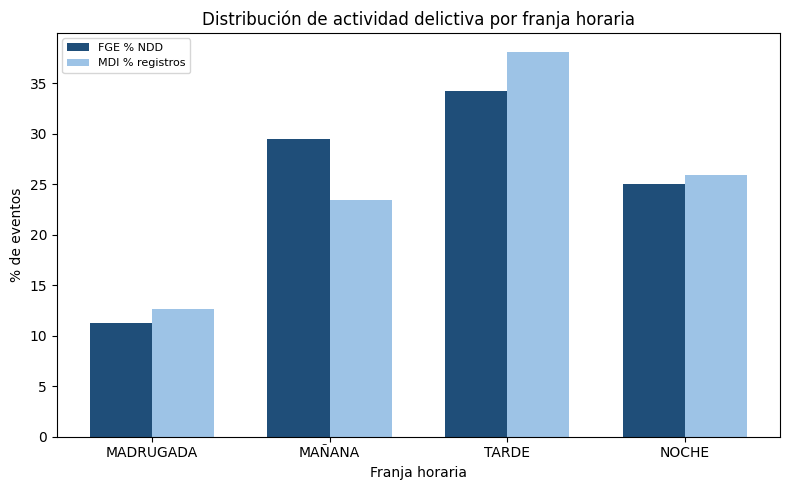

In [8]:
# =====================================================================
# 7. FIGURA A — distribución por franja horaria (FGE vs MDI vs modelo)
# =====================================================================
fig, ax1 = plt.subplots(figsize=(8,5))
x = np.arange(len(ORDEN_FRANJA)); w = 0.35
ax1.bar(x-w/2, (fge_band/fge_band.sum()*100).values, w, label="FGE % NDD", color="#1F4E79")
ax1.bar(x+w/2, (mdi_band/mdi_band.sum()*100).values, w, label="MDI % registros", color="#9DC3E6")
ax1.set_xticks(x); ax1.set_xticklabels(ORDEN_FRANJA)
ax1.set_ylabel("% de eventos"); ax1.set_xlabel("Franja horaria")
if modelo_ok:
    ax2 = ax1.twinx()
    ax2.plot(x, sev_band.values, "o-", color="#C00000", label="Danger score medio (modelo)")
    ax2.set_ylabel("Danger score medio (0-100)")
    l1,lab1 = ax1.get_legend_handles_labels(); l2,lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, lab1+lab2, loc="upper left", fontsize=8)
else:
    ax1.legend(loc="upper left", fontsize=8)
plt.title("Distribución de actividad delictiva por franja horaria")
plt.tight_layout(); plt.savefig("fig_franja_horaria.png", dpi=150); plt.show()

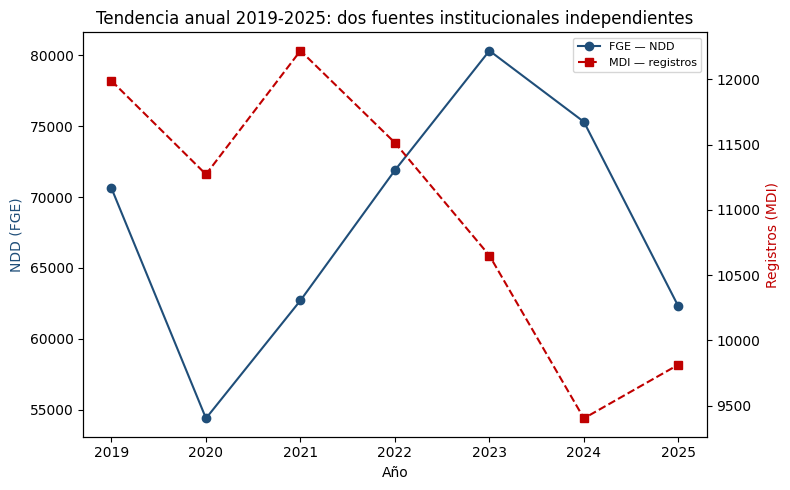

In [9]:
# =====================================================================
# 8. FIGURA B — tendencia anual (FGE NDD vs MDI registros)
# =====================================================================
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(fge_year.index, fge_year.values, "o-", color="#1F4E79", label="FGE — NDD")
ax1.set_xlabel("Año"); ax1.set_ylabel("NDD (FGE)", color="#1F4E79")
ax2 = ax1.twinx()
ax2.plot(mdi_year.index, mdi_year.values, "s--", color="#C00000", label="MDI — registros")
ax2.set_ylabel("Registros (MDI)", color="#C00000")
l1,lab1 = ax1.get_legend_handles_labels(); l2,lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lab1+lab2, loc="upper right", fontsize=8)
plt.title("Tendencia anual 2019-2025: dos fuentes institucionales independientes")
plt.tight_layout(); plt.savefig("fig_tendencia_anual.png", dpi=150); plt.show()

In [10]:
# =====================================================================
# 9. RESUMEN FINAL — manda CAPTURA de esta salida
# =====================================================================
print("="*60)
print("RESUMEN §4.4.2 — CONSISTENCIA TEMPORAL FGE vs MODELO/MDI")
print("="*60)
print(f"FGE: {int(fge['TOTAL_NDD'].sum()):,} NDD | MDI: {len(mdi):,} registros | periodo {PERIODO[0]}-{PERIODO[1]}")
print("\n-- ANUAL (frecuencia, fuentes independientes) --")
comparar(fge_year, mdi_year, "FGE vs MDI 2019-2025")
comparar(fge_year.loc[2019:2022], mdi_year.loc[2019:2022], "FGE vs MDI 2019-2022")
if modelo_ok:
    comparar(fge_year, sev_year, "FGE vs gravedad modelo 2019-2025")
print("\n-- FRANJA HORARIA (descriptivo) --")
print(tabla_franja.to_string())
print("\nModelo cargado y predicho:", modelo_ok)

RESUMEN §4.4.2 — CONSISTENCIA TEMPORAL FGE vs MODELO/MDI
FGE: 477,527 NDD | MDI: 76,860 registros | periodo 2019-2025

-- ANUAL (frecuencia, fuentes independientes) --
[FGE vs MDI 2019-2025] n=7 | Spearman rho=-0.2500  p=0.5887 | acuerdo direccional=50%
[FGE vs MDI 2019-2022] n=4 | Spearman rho=0.2000  p=0.8000 | acuerdo direccional=67%

-- FRANJA HORARIA (descriptivo) --
           FGE_%NDD  MDI_%reg
MADRUGADA      11.2      12.6
MAÑANA         29.5      23.4
TARDE          34.3      38.1
NOCHE          25.0      25.9

Modelo cargado y predicho: False
